# Compare Single-Task vs Ensemble Predictions

Compare **single** Graph Transformer models (v1.6.0, one model per endpoint)
against the **beardy-polonium** ensemble submission (v1.3.0, ensemble of
multi-task models) on **LogD** and **KSOL** endpoints.

KSOL predictions are in raw assay units and must be log-transformed
(`log10((KSOL + 1) * 1e-6)`) before evaluation so that metrics are
computed in the same log space used during training.

## Usage

1. Ensure submission CSVs are in `data/submissions/`
2. Run all cells

In [1]:
# =============================================================================
# Configuration
# =============================================================================

ENDPOINTS = ["LogD", "KSOL"]

# Submission files: {display label: csv path}
SUBMISSIONS = {
    "Single-task (v1.6.0)": {
        "LogD": "data/submissions/submission_logd_st.csv",
        "KSOL": "data/submissions/submission_ksol_st.csv",
    },
    "Ensemble (v1.3.0)": {
        "LogD": "data/submissions/beardy-polonium-submission.csv",
        "KSOL": "data/submissions/beardy-polonium-submission.csv",
    },
}

GROUND_TRUTH_PATH = "data/test-set/expansion_data_test_full_lb_flag.csv"

N_BOOTSTRAP = 1000

print(f"Endpoints : {ENDPOINTS}")
print(f"Models    : {list(SUBMISSIONS.keys())}")
print(f"Bootstrap : {N_BOOTSTRAP}")

Endpoints : ['LogD', 'KSOL']
Models    : ['Single-task (v1.6.0)', 'Ensemble (v1.3.0)']
Bootstrap : 1000


In [2]:
# =============================================================================
# Imports
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, Tuple
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.precision", 4)

METRICS = ["MAE", "RAE", "R2", "Spearman R", "Kendall's Tau"]
LOWER_IS_BETTER = {"MAE", "RAE"}

In [3]:
# =============================================================================
# Helpers
# =============================================================================

# Endpoint -> (log_scale, multiplier), mirrors src/utils.py get_conversion_df()
ENDPOINT_TRANSFORMS = {
    "LogD": (False, 1.0),
    "KSOL": (True, 1e-6),
    "HLM CLint": (True, 1.0),
    "MLM CLint": (True, 1.0),
    "Caco-2 Permeability Papp A>B": (True, 1e-6),
    "Caco-2 Permeability Efflux": (True, 1.0),
    "MPPB": (True, 1.0),
    "MBPB": (True, 1.0),
    "MGMB": (True, 1.0),
}

SPLITS = ["all", "leaderboard", "private"]


def _to_log_space(y: np.ndarray, endpoint: str) -> np.ndarray:
    """Transform raw assay values to the log space used for training/evaluation.

    Applies log10((clip(y, 0) + 1) * multiplier) for log-scale endpoints.
    No-op for endpoints already in log space (e.g. LogD).
    """
    log_scale, multiplier = ENDPOINT_TRANSFORMS[endpoint]
    if not log_scale:
        return y
    return np.log10((np.clip(y, 0, None) + 1) * multiplier)


def compute_metrics(pred: np.ndarray, true: np.ndarray) -> Dict[str, float]:
    mae = mean_absolute_error(true, pred)
    rae = mae / np.mean(np.abs(true - np.mean(true)))
    r2 = r2_score(true, pred) if np.std(true) > 0 else np.nan
    spr = spearmanr(true, pred).statistic
    ktau = kendalltau(true, pred).statistic
    return {
        "MAE": mae, "RAE": rae, "R2": r2,
        "Spearman R": spr, "Kendall's Tau": ktau,
    }


def bootstrap_evaluate(
    y_pred: np.ndarray, y_true: np.ndarray,
    n_bootstrap: int, seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        rows.append(compute_metrics(y_pred[idx], y_true[idx]))
    return pd.DataFrame(rows)


def _find_pred_column(df: pd.DataFrame, endpoint: str) -> str:
    """Locate the prediction column in a submission CSV."""
    if endpoint in df.columns:
        return endpoint
    id_cols = {"SMILES", "Molecule Name"}
    candidates = [c for c in df.columns if c not in id_cols]
    if len(candidates) == 1:
        return candidates[0]
    raise ValueError(
        f"Cannot auto-detect prediction column for '{endpoint}'. "
        f"Columns found: {df.columns.tolist()}"
    )


def get_aligned(
    pred_df: pd.DataFrame, truth_df: pd.DataFrame, endpoint: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (y_pred, y_true, is_leaderboard) aligned on Molecule Name, in eval space."""
    pred_col = _find_pred_column(pred_df, endpoint)
    left = pred_df[["Molecule Name", pred_col]].rename(
        columns={pred_col: "_pred"}
    )
    right = truth_df[["Molecule Name", endpoint, "is_leaderboard"]].rename(
        columns={endpoint: "_true"}
    )
    merged = left.merge(right, on="Molecule Name").dropna(
        subset=["_pred", "_true"]
    )
    y_pred = merged["_pred"].to_numpy(dtype=float)
    y_true = merged["_true"].to_numpy(dtype=float)
    is_lb = merged["is_leaderboard"].to_numpy(dtype=int)
    y_pred = _to_log_space(y_pred, endpoint)
    y_true = _to_log_space(y_true, endpoint)
    return y_pred, y_true, is_lb


def get_split_mask(is_lb: np.ndarray, split: str) -> np.ndarray:
    """Return boolean mask for a given split."""
    if split == "all":
        return np.ones(len(is_lb), dtype=bool)
    elif split == "leaderboard":
        return is_lb == 1
    elif split == "private":
        return is_lb == 0
    else:
        raise ValueError(f"Unknown split: {split}")


def bootstrap_significance(
    bs1: pd.DataFrame, bs2: pd.DataFrame, metric: str,
) -> Tuple[float, bool]:
    """p-value that model-2 is NOT better; bool = model-2 IS better on average."""
    diff = bs2[metric].values - bs1[metric].values
    if metric in LOWER_IS_BETTER:
        return float(np.mean(diff >= 0)), bool(np.mean(diff) < 0)
    return float(np.mean(diff <= 0)), bool(np.mean(diff) > 0)

## Load Data and Evaluate

For each endpoint, load the ground truth and submission CSVs, align on
molecule name, transform KSOL to log space, and compute bootstrap metrics.

In [4]:
ground_truth = pd.read_csv(GROUND_TRUTH_PATH)
print(f"Ground truth: {ground_truth.shape[0]} molecules")
for ep in ENDPOINTS:
    n_gt = ground_truth[ep].notna().sum()
    lb_n = ground_truth.loc[ground_truth["is_leaderboard"] == 1, ep].notna().sum()
    priv_n = ground_truth.loc[ground_truth["is_leaderboard"] == 0, ep].notna().sum()
    print(f"  {ep}: {n_gt} total (leaderboard={lb_n}, private={priv_n})")

model_names = list(SUBMISSIONS.keys())

# results[endpoint][split][model_label] = {y_pred, y_true, n, metrics}
results = {ep: {s: {} for s in SPLITS} for ep in ENDPOINTS}
bootstrap_results = {ep: {s: {} for s in SPLITS} for ep in ENDPOINTS}

# Raw aligned arrays (before splitting)
aligned = {ep: {} for ep in ENDPOINTS}

for ep in ENDPOINTS:
    print(f"\n{'=' * 60}")
    print(f"Endpoint: {ep}")
    print(f"{'=' * 60}")
    for label in model_names:
        path = SUBMISSIONS[label][ep]
        df = pd.read_csv(path)
        pred_col = _find_pred_column(df, ep)
        y_pred, y_true, is_lb = get_aligned(df, ground_truth, ep)
        aligned[ep][label] = (y_pred, y_true, is_lb)

        for split in SPLITS:
            mask = get_split_mask(is_lb, split)
            yp, yt = y_pred[mask], y_true[mask]
            bs = bootstrap_evaluate(yp, yt, N_BOOTSTRAP)
            bootstrap_results[ep][split][label] = bs
            results[ep][split][label] = {
                "y_pred": yp, "y_true": yt, "n": len(yt),
                "pred_col": pred_col,
                "metrics": {m: (bs[m].mean(), bs[m].std()) for m in METRICS},
            }

        # Print summary for all split
        m_all = results[ep]["all"][label]["metrics"]
        print(
            f"  {label:25s} | col='{pred_col}' | "
            f"n={results[ep]['all'][label]['n']} | "
            f"MAE={m_all['MAE'][0]:.4f}\u00b1{m_all['MAE'][1]:.4f}"
        )

Ground truth: 2282 molecules
  LogD: 2270 total (leaderboard=1140, private=1130)
  KSOL: 2170 total (leaderboard=1130, private=1040)

Endpoint: LogD
  Single-task (v1.6.0)      | col='LogD' | n=2270 | MAE=0.3728±0.0077
  Ensemble (v1.3.0)         | col='LogD' | n=2270 | MAE=0.3809±0.0077

Endpoint: KSOL
  Single-task (v1.6.0)      | col='KSOL' | n=2170 | MAE=0.3301±0.0087
  Ensemble (v1.3.0)         | col='KSOL' | n=2170 | MAE=0.3460±0.0066


## Results Summary

Metrics for each endpoint, split by **all**, **leaderboard** (public),
and **private** test sets.

In [5]:
for ep in ENDPOINTS:
    for split in SPLITS:
        rows = []
        for name in model_names:
            m = results[ep][split][name]
            row = {"Model": name, "n": m["n"]}
            for metric in METRICS:
                mean, std = m["metrics"][metric]
                row[metric] = f"{mean:.4f}\u00b1{std:.4f}"
                row[f"{metric}_mean"] = mean
            rows.append(row)

        summary_df = pd.DataFrame(rows)

        print(f"\n{'=' * 80}")
        print(f"{ep} — {split}")
        print(f"{'=' * 80}")
        display(summary_df[["Model", "n"] + METRICS].set_index("Model"))


LogD — all


,n,MAE,RAE,R2,Spearman R,Kendall's Tau
Model,,,,,,
Single-task (v1.6.0),2270,0.3728±0.0077,0.4595±0.0108,0.7461±0.0137,0.8618±0.0081,0.7082±0.0085
Ensemble (v1.3.0),2270,0.3809±0.0077,0.4695±0.0099,0.7343±0.0143,0.8712±0.0070,0.7108±0.0077



LogD — leaderboard


,n,MAE,RAE,R2,Spearman R,Kendall's Tau
Model,,,,,,
Single-task (v1.6.0),1140,0.2854±0.0082,0.3412±0.0106,0.8667±0.0118,0.9291±0.0068,0.7935±0.0084
Ensemble (v1.3.0),1140,0.3427±0.0116,0.4092±0.0129,0.7684±0.0220,0.8995±0.0085,0.7491±0.0098



LogD — private


...

,n,MAE,RAE,R2,Spearman R,Kendall's Tau
Model,,,,,,
Single-task (v1.6.0),2170,0.3301±0.0087,0.5751±0.0169,0.4581±0.0279,0.5406±0.0171,0.3772±0.0133
Ensemble (v1.3.0),2170,0.3460±0.0066,0.6023±0.0149,0.5656±0.0187,0.6228±0.0145,0.4421±0.0118



KSOL — leaderboard


,n,MAE,RAE,R2,Spearman R,Kendall's Tau
Model,,,,,,
Single-task (v1.6.0),1130,0.3671±0.0120,0.5533±0.0207,0.4978±0.0330,0.6737±0.0181,0.4872±0.0153
Ensemble (v1.3.0),1130,0.3646±0.0092,0.5490±0.0163,0.6151±0.0217,0.7208±0.0163,0.5287±0.0145



KSOL — private


,n,MAE,RAE,R2,Spearman R,Kendall's Tau
Model,,,,,,
Single-task (v1.6.0),1040,0.2901±0.0123,0.7357±0.0375,0.2682±0.0595,0.2962±0.0305,0.1982±0.0214
Ensemble (v1.3.0),1040,0.3249±0.0099,0.8231±0.0392,0.3816±0.0379,0.4507±0.0271,0.3098±0.0201


## Pairwise Significance

Bootstrap significance tests (single-task vs ensemble) per endpoint and split.

In [6]:
def significance_matrix(metric: str, ep: str, split: str) -> pd.DataFrame:
    mat = pd.DataFrame(index=model_names, columns=model_names, dtype=object)
    for m1 in model_names:
        for m2 in model_names:
            if m1 == m2:
                mat.loc[m1, m2] = "-"
            else:
                p, is_better = bootstrap_significance(
                    bootstrap_results[ep][split][m1],
                    bootstrap_results[ep][split][m2],
                    metric,
                )
                sig = "**" if p < 0.01 else "*" if p < 0.05 else ""
                arrow = "\u2191" if is_better else "\u2193"
                mat.loc[m1, m2] = f"{p:.3f}{sig}{arrow}"
    return mat


print("P(column better than row)")
print("\u2191 = column wins, \u2193 = row wins, * p<0.05, ** p<0.01\n")

for ep in ENDPOINTS:
    for split in SPLITS:
        print(f"\n{'—' * 60}")
        print(f"{ep} — {split}")
        print(f"{'—' * 60}")
        for metric in ["MAE", "R2", "Spearman R"]:
            print(f"\n{metric}:")
            display(significance_matrix(metric, ep, split))

P(column better than row)
↑ = column wins, ↓ = row wins, * p<0.05, ** p<0.01


————————————————————————————————————————————————————————————
LogD — all
————————————————————————————————————————————————————————————

MAE:


,Single-task (v1.6.0),Ensemble (v1.3.0)
Single-task (v1.6.0),-,0.772↓
Ensemble (v1.3.0),0.228↑,-



R2:


,Single-task (v1.6.0),Ensemble (v1.3.0)
Single-task (v1.6.0),-,0.743↓
Ensemble (v1.3.0),0.257↑,-



Spearman R:


...

,Single-task (v1.6.0),Ensemble (v1.3.0)
Single-task (v1.6.0),-,0.990↓
Ensemble (v1.3.0),0.010*↑,-



R2:


,Single-task (v1.6.0),Ensemble (v1.3.0)
Single-task (v1.6.0),-,0.047*↑
Ensemble (v1.3.0),0.953↓,-



Spearman R:


,Single-task (v1.6.0),Ensemble (v1.3.0)
Single-task (v1.6.0),-,0.000**↑
Ensemble (v1.3.0),1.000↓,-


## Bar Comparison

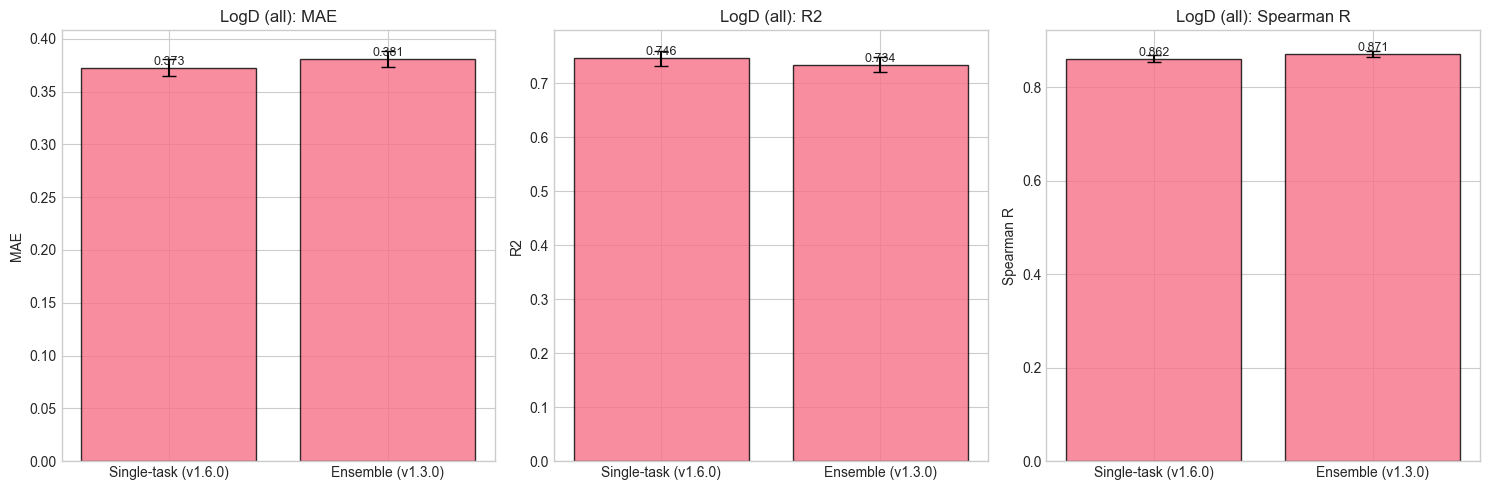

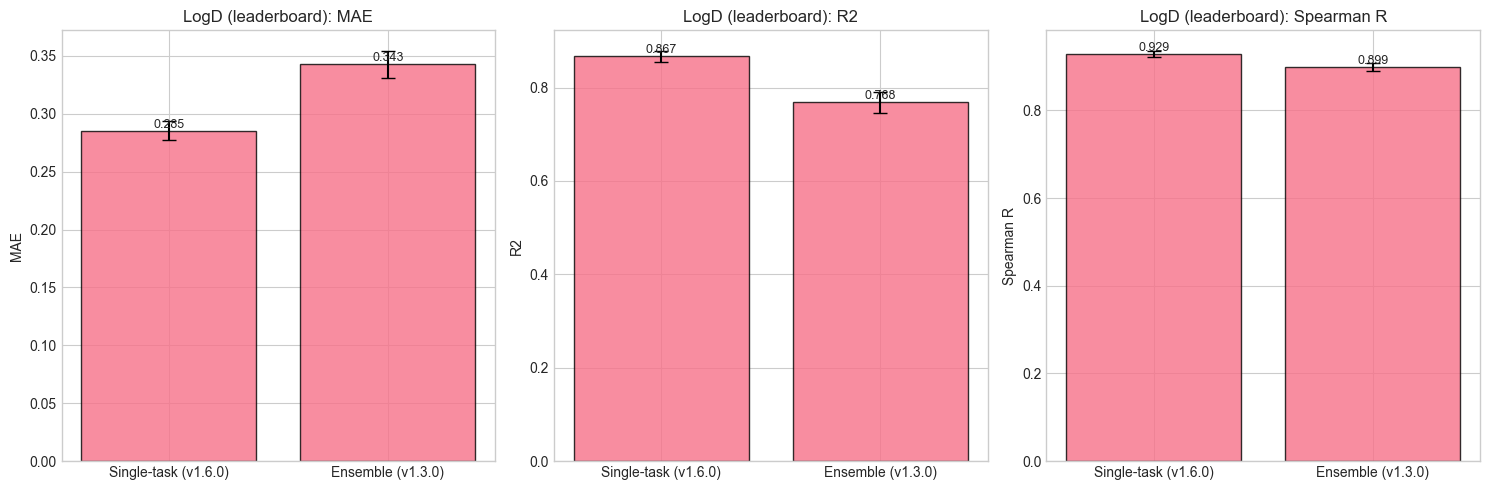

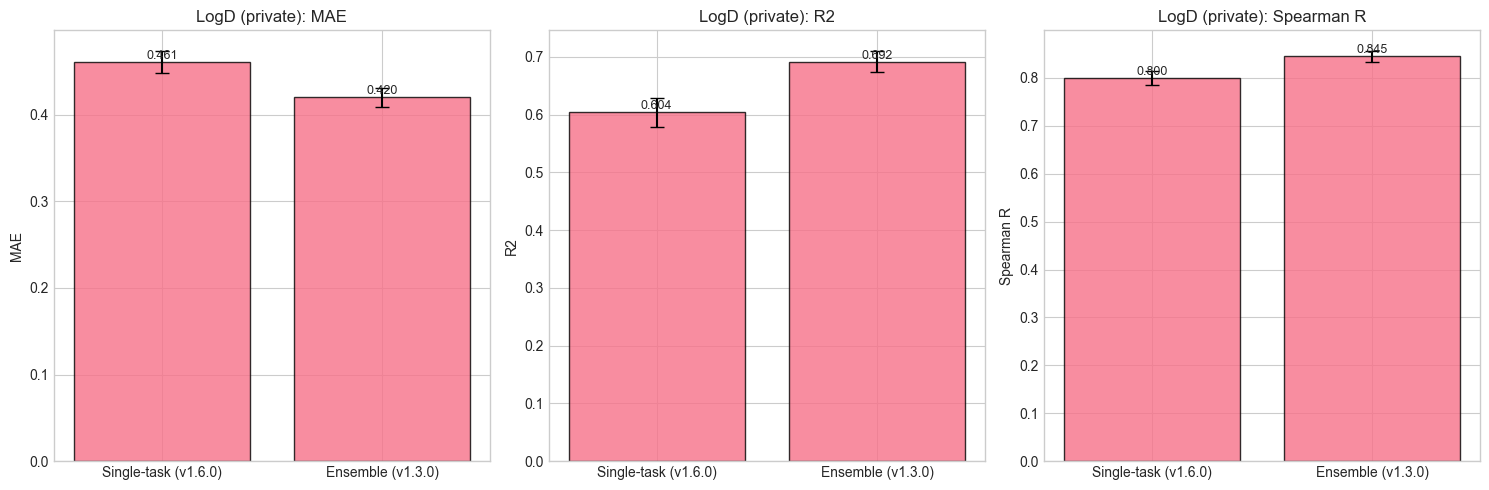

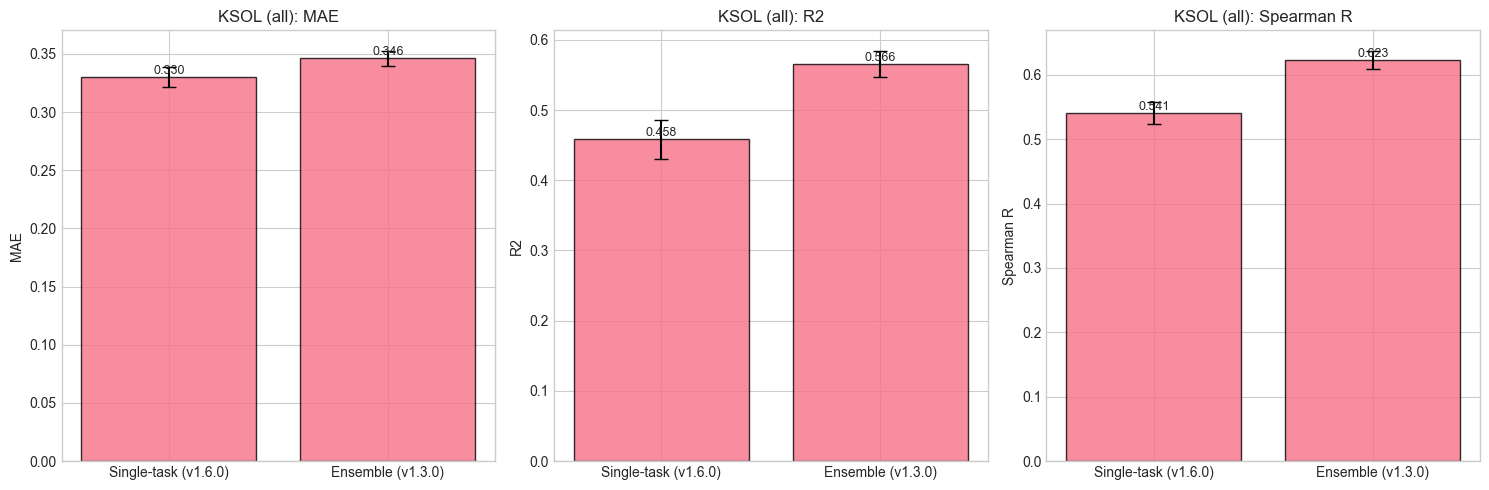

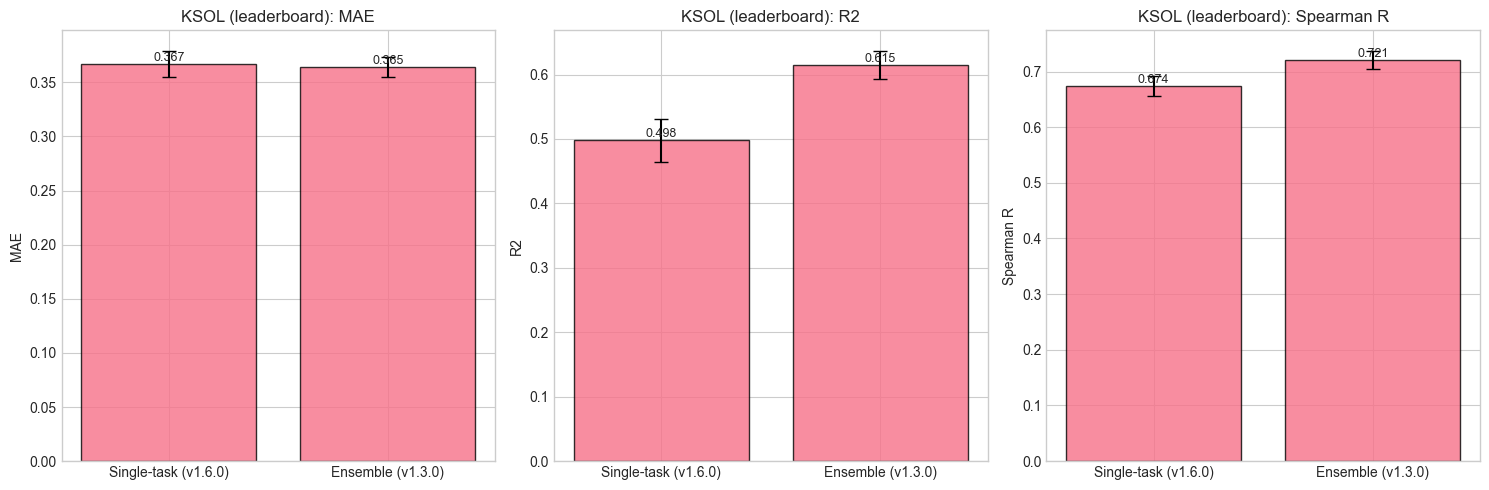

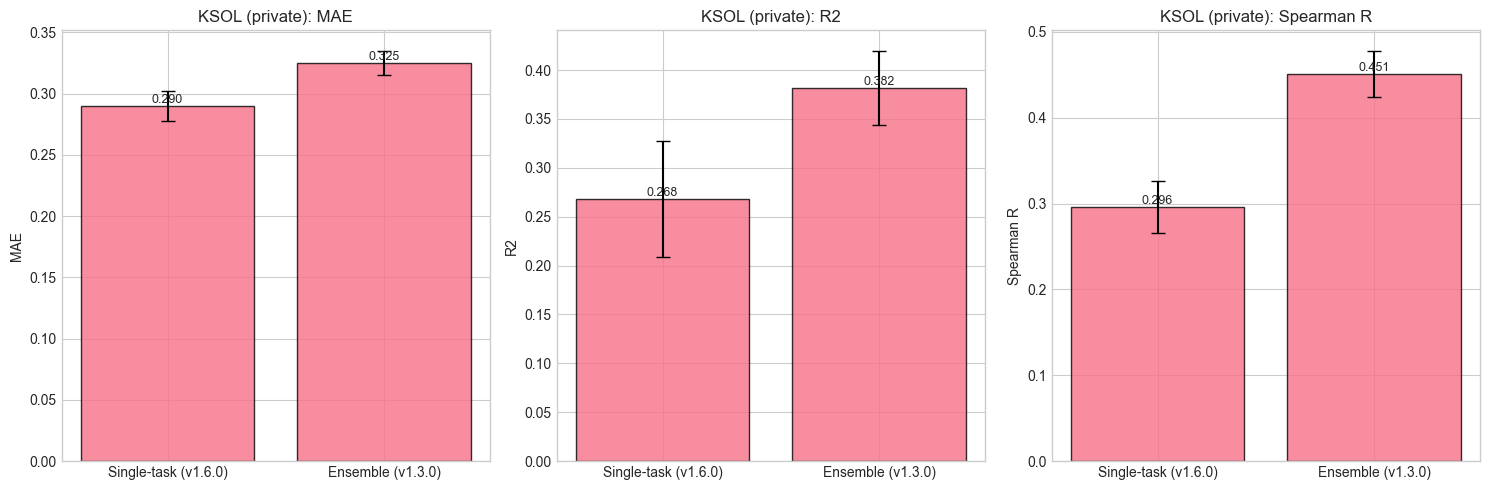

In [7]:
for ep in ENDPOINTS:
    for split in SPLITS:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        models_s = results[ep][split]

        for ax, metric in zip(axes, ["MAE", "R2", "Spearman R"]):
            means = [models_s[n]["metrics"][metric][0] for n in model_names]
            stds = [models_s[n]["metrics"][metric][1] for n in model_names]
            bars = ax.bar(
                model_names, means, yerr=stds, capsize=5,
                edgecolor="black", alpha=0.8,
            )
            ax.set_ylabel(metric)
            ax.set_title(f"{ep} ({split}): {metric}")
            for bar, val in zip(bars, means):
                ax.text(
                    bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9,
                )

        plt.tight_layout()
        plt.show()

## Scatter Plots (Predicted vs True)

Scatter plots on the **all** split for both endpoints.

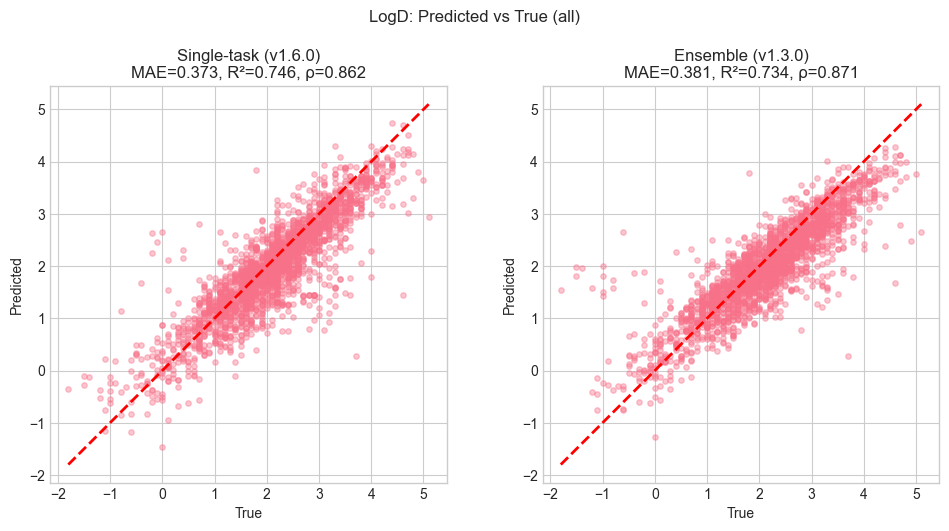

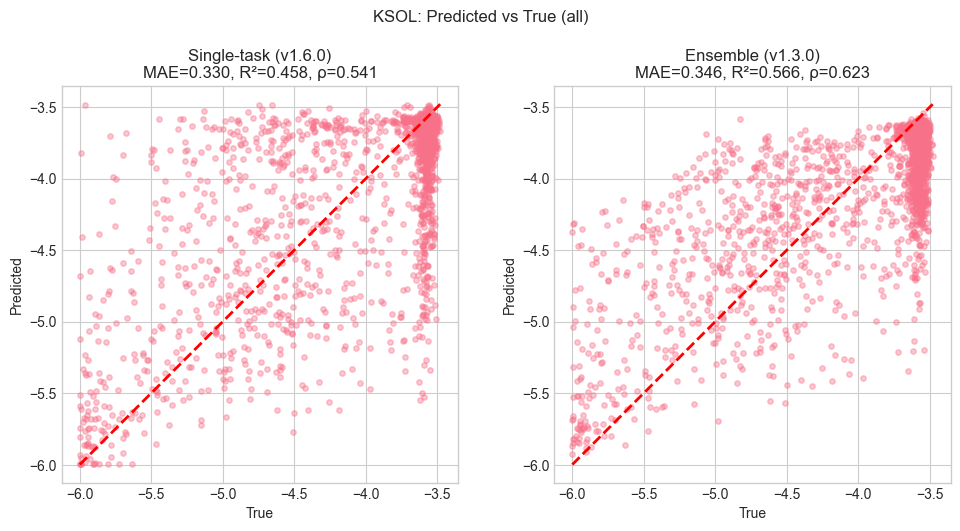

In [8]:
n_models = len(model_names)

for ep in ENDPOINTS:
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    models_all = results[ep]["all"]
    for ax, name in zip(axes, model_names):
        m = models_all[name]
        ax.scatter(m["y_true"], m["y_pred"], alpha=0.4, s=15)
        lims = [
            min(m["y_true"].min(), m["y_pred"].min()),
            max(m["y_true"].max(), m["y_pred"].max()),
        ]
        ax.plot(lims, lims, "r--", lw=2)
        mae = m["metrics"]["MAE"][0]
        r2 = m["metrics"]["R2"][0]
        spr = m["metrics"]["Spearman R"][0]
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name}\nMAE={mae:.3f}, R\u00b2={r2:.3f}, \u03c1={spr:.3f}")
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(f"{ep}: Predicted vs True (all)", y=1.02)
    plt.tight_layout()
    plt.show()

## Bootstrap Distributions

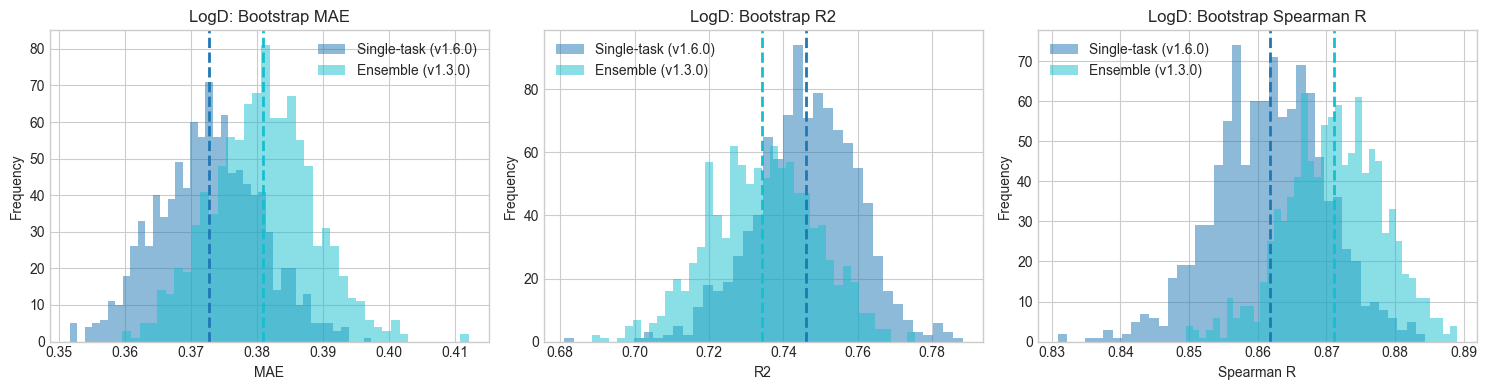

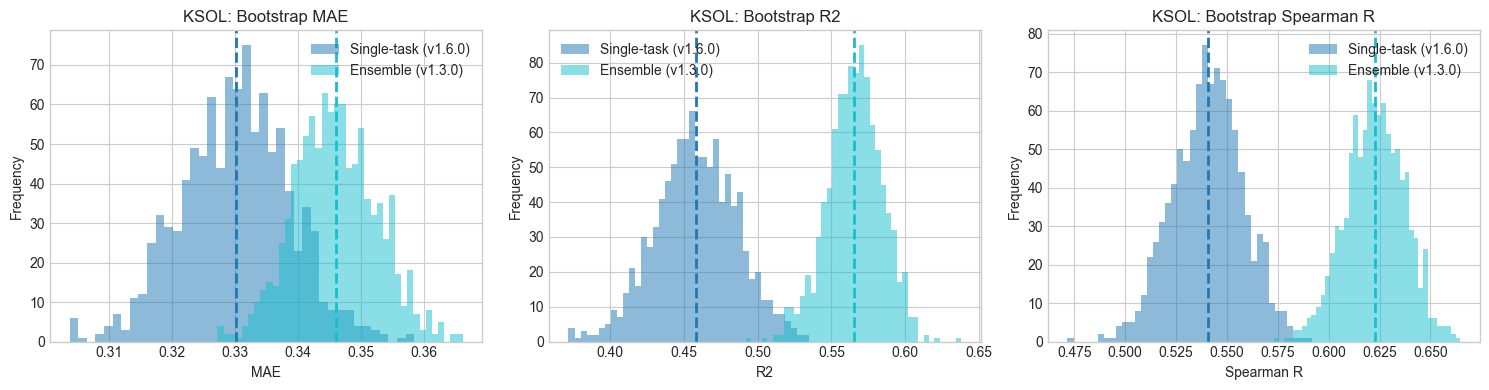

In [9]:
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for ep in ENDPOINTS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, metric in zip(axes, ["MAE", "R2", "Spearman R"]):
        for name, color in zip(model_names, colors):
            data = bootstrap_results[ep]["all"][name][metric]
            ax.hist(data, bins=40, alpha=0.5, label=name, color=color)
            ax.axvline(data.mean(), color=color, linestyle="--", lw=2)
        ax.set_xlabel(metric)
        ax.set_ylabel("Frequency")
        ax.set_title(f"{ep}: Bootstrap {metric}")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Residual Analysis

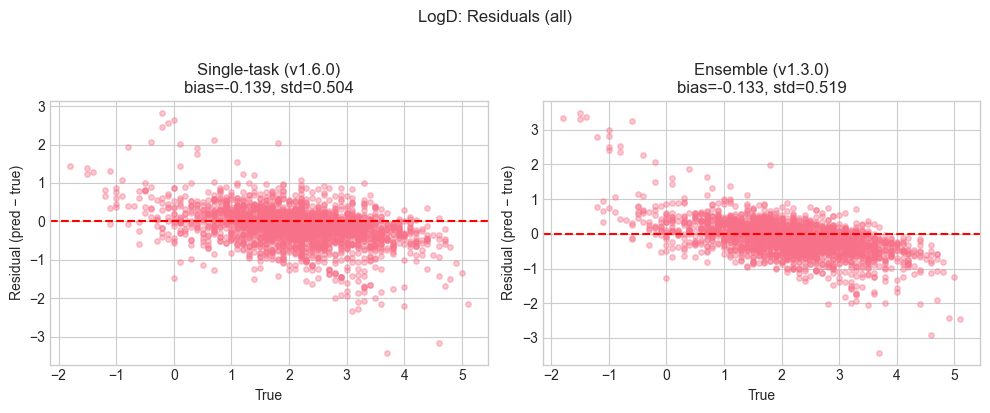

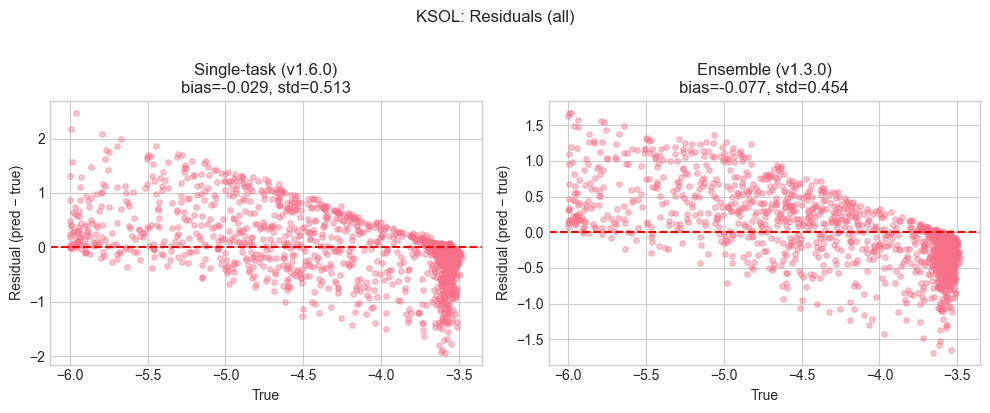

In [10]:
for ep in ENDPOINTS:
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
    if n_models == 1:
        axes = [axes]

    models_all = results[ep]["all"]
    for ax, name in zip(axes, model_names):
        m = models_all[name]
        residuals = m["y_pred"] - m["y_true"]
        ax.scatter(m["y_true"], residuals, alpha=0.4, s=15)
        ax.axhline(0, color="r", linestyle="--", lw=1.5)
        ax.set_xlabel("True")
        ax.set_ylabel("Residual (pred \u2212 true)")
        ax.set_title(f"{name}\nbias={np.mean(residuals):+.3f}, std={np.std(residuals):.3f}")

    fig.suptitle(f"{ep}: Residuals (all)", y=1.02)
    plt.tight_layout()
    plt.show()

## Summary

In [11]:
def _best(metric: str, models_dict: dict) -> str:
    if metric in LOWER_IS_BETTER:
        return min(model_names, key=lambda n: models_dict[n]["metrics"][metric][0])
    return max(model_names, key=lambda n: models_dict[n]["metrics"][metric][0])


from collections import Counter

for ep in ENDPOINTS:
    for split in SPLITS:
        models_s = results[ep][split]
        print(f"\n{'=' * 60}")
        print(f"{ep} — {split}")
        print(f"{'=' * 60}")

        print("\nBest model per metric:")
        for metric in METRICS:
            best = _best(metric, models_s)
            mean, std = models_s[best]["metrics"][metric]
            print(f"  {metric:15s}: {best} = {mean:.4f}\u00b1{std:.4f}")

        wins = Counter(_best(m, models_s) for m in METRICS)
        overall = wins.most_common(1)[0]
        print(f"\n  Overall best: {overall[0]} ({overall[1]}/{len(METRICS)} metrics)")


LogD — all

Best model per metric:
  MAE            : Single-task (v1.6.0) = 0.3728±0.0077
  RAE            : Single-task (v1.6.0) = 0.4595±0.0108
  R2             : Single-task (v1.6.0) = 0.7461±0.0137
  Spearman R     : Ensemble (v1.3.0) = 0.8712±0.0070
  Kendall's Tau  : Ensemble (v1.3.0) = 0.7108±0.0077

  Overall best: Single-task (v1.6.0) (3/5 metrics)

LogD — leaderboard

Best model per metric:
  MAE            : Single-task (v1.6.0) = 0.2854±0.0082
  RAE            : Single-task (v1.6.0) = 0.3412±0.0106
  R2             : Single-task (v1.6.0) = 0.8667±0.0118
  Spearman R     : Single-task (v1.6.0) = 0.9291±0.0068
  Kendall's Tau  : Single-task (v1.6.0) = 0.7935±0.0084

  Overall best: Single-task (v1.6.0) (5/5 metrics)

LogD — private

Best model per metric:
  MAE            : Ensemble (v1.3.0) = 0.4202±0.0107
  RAE            : Ensemble (v1.3.0) = 0.5351±0.0152
  R2             : Ensemble (v1.3.0) = 0.6918±0.0187
  Spearman R     : Ensemble (v1.3.0) = 0.8452±0.0111
  Kendall'